In [1]:
import numpy as np
#from game.game import Game
from env.wrapper import EnvWrapper

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
from game.enums import BoardType, Tribes, ActionTypes, UnitType, UnitState

In [3]:
board_config = {
        "board_size" : (10,10),
        "board_type" : BoardType.Dummy,
        "n_players" : 2,
}
player_tribes = [Tribes.Omaji, Tribes.Imperius]

In [4]:
env1 = EnvWrapper(board_config, player_tribes, dense_reward=True)

In [5]:
env1.reset() # returns _get_obs() for the first player to start

{'partial_graph': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 26)),
 'units': [<game.components.units.Warrior at 0x1c6a8ce2850>],
 'cities': [<game.components.city.City at 0x1c6a8fb60d0>],
 'enemy_units': [<game.components.units.Warrior at 0x1c6a8cea8b0>]}

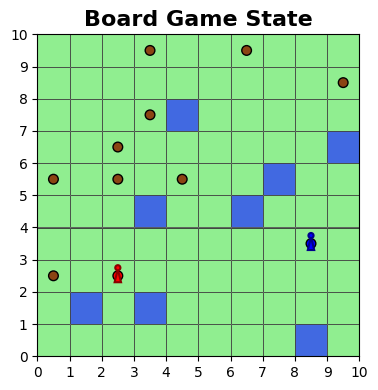

In [6]:
env1.render()

In [7]:
env1.get_action_mask()

[array([1., 0., 0., 0., 0.]),
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]]),
 array([[0.]]),
 array([[0., 0.]]),
 array([0.])]

In [8]:
env1._get_obs()

{'partial_graph': array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 26)),
 'units': [<game.components.units.Warrior at 0x1c6a8ce2850>],
 'cities': [<game.components.city.City at 0x1c6a8fb60d0>],
 'enemy_units': [<game.components.units.Warrior at 0x1c6a8cea8b0>]}

# Make random policy network to get things started


In [9]:
EMBED_DIM    = 16
N_ACTIONS    = len(ActionTypes)   # 5
N_UNIT_TYPES = len(UnitType)         
N_EPISODES   = 20
MAX_STEPS    = 1000
LR           = 1e-3
GAMMA        = 0.99

In [10]:
class PairwiseHead(nn.Module):
    """Computes logits of shape (n_q, n_k) via scaled dot-product attention."""
    def __init__(self, embed_dim):
        super().__init__()
        self.q = nn.Linear(embed_dim, embed_dim, bias=False)
        self.k = nn.Linear(embed_dim, embed_dim, bias=False)
        self.scale = embed_dim ** 0.5

    def forward(self, q_emb, k_emb):
        # q_emb: (n_q, D)  k_emb: (n_k, D)
        return self.q(q_emb) @ self.k(k_emb).T / self.scale   # (n_q, n_k)

In [11]:
class DummyPolicy(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, n_actions=N_ACTIONS,
                 n_unit_types=N_UNIT_TYPES):
        super().__init__()
        D = embed_dim

        # Learned "global" context vector (replaces real obs encoding)
        self.global_ctx = nn.Parameter(torch.randn(1, D))

        # Fixed-vocab embeddings
        self.tile_emb      = nn.Embedding(100, D)   
        self.unit_type_emb = nn.Embedding(n_unit_types, D)

        # Heads
        self.action_type_head = nn.Linear(D, n_actions)
        self.unit_sel   = PairwiseHead(D)   # global → units
        self.tile_sel   = PairwiseHead(D)   # unit   → tiles
        self.enemy_sel  = PairwiseHead(D)   # unit   → enemy units
        self.city_sel   = PairwiseHead(D)   # global → cities
        self.utype_sel  = PairwiseHead(D)   # city   → unit types

    # ------------------------------------------------------------------
    def _rand_emb(self, n):
        """Random embeddings for n dynamically-sized entities."""
        return torch.randn(n, self.global_ctx.shape[1],
                           device=self.global_ctx.device)

    def _masked_cat(self, logits, mask_np):
        """Apply binary mask (numpy) and return Categorical distribution."""
        mask = torch.tensor(mask_np, dtype=torch.float32,
                            device=logits.device)
        logits = logits + torch.log(mask.clamp(min=1e-8))
        return torch.distributions.Categorical(logits=logits)

    # ------------------------------------------------------------------
    def forward(self, obs, action_mask):
        ctx = self.global_ctx                              # (1, D)
        n_units  = len(obs["units"])
        n_enemy  = len(obs["enemy_units"])
        n_cities = len(obs["cities"])

        # ── Action type ───────────────────────────────────────────────
        at_logits = self.action_type_head(ctx).squeeze(0)  # (n_actions,)
        at_dist   = self._masked_cat(at_logits, action_mask[0])
        at        = at_dist.sample()
        log_p     = at_dist.log_prob(at)
        atype     = at.item()

        # ── Subaction heads ───────────────────────────────────────────
        if atype == ActionTypes.MoveUnit:
            u_emb  = self._rand_emb(n_units)
            t_emb  = self.tile_emb.weight                  # (n_tiles, D)

            u_dist = self._masked_cat(
                self.unit_sel(ctx, u_emb).squeeze(0),       # (n_units,)
                action_mask[1].max(axis=1))
            uid    = u_dist.sample()
            log_p  = log_p + u_dist.log_prob(uid)

            t_dist = self._masked_cat(
                self.tile_sel(u_emb[uid:uid+1], t_emb).squeeze(0),  # (n_tiles,)
                action_mask[1][uid.item()])
            tid    = t_dist.sample()
            log_p  = log_p + t_dist.log_prob(tid)

            action = [atype, uid.item(), tid.item()]

        elif atype == ActionTypes.Attack:
            u_emb  = self._rand_emb(n_units)
            e_emb  = self._rand_emb(n_enemy)

            u_dist = self._masked_cat(
                self.unit_sel(ctx, u_emb).squeeze(0),
                action_mask[2].max(axis=1))
            uid    = u_dist.sample()
            log_p  = log_p + u_dist.log_prob(uid)

            e_dist = self._masked_cat(
                self.enemy_sel(u_emb[uid:uid+1], e_emb).squeeze(0),
                action_mask[2][uid.item()])
            eid    = e_dist.sample()
            log_p  = log_p + e_dist.log_prob(eid)

            action = [atype, uid.item(), eid.item()]

        elif atype == ActionTypes.CreateUnit:
            c_emb  = self._rand_emb(n_cities)
            ut_emb = self.unit_type_emb.weight

            c_dist = self._masked_cat(
                self.city_sel(ctx, c_emb).squeeze(0),
                action_mask[3].max(axis=1))
            cid    = c_dist.sample()
            log_p  = log_p + c_dist.log_prob(cid)

            ut_dist = self._masked_cat(
                self.utype_sel(c_emb[cid:cid+1], ut_emb).squeeze(0),
                action_mask[3][cid.item()])
            utid    = ut_dist.sample()
            log_p   = log_p + ut_dist.log_prob(utid)

            action  = [atype, cid.item(), utid.item()]

        elif atype == ActionTypes.CaptureCity:
            u_emb  = self._rand_emb(n_units)
            u_dist = self._masked_cat(
                self.unit_sel(ctx, u_emb).squeeze(0),
                action_mask[4])
            uid    = u_dist.sample()
            log_p  = log_p + u_dist.log_prob(uid)
            action = [atype, uid.item()]

        else:  # EndTurn
            action = [atype]

        return action, log_p

In [12]:
def discount_returns(rewards, gamma=GAMMA):
    G, returns = 0.0, []
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    return returns

In [13]:
env = env1

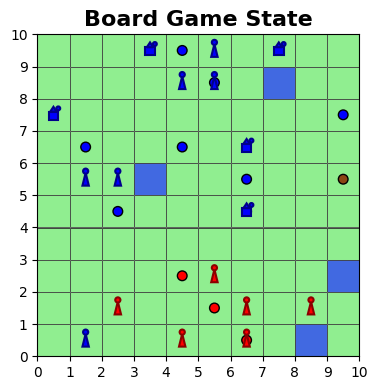

ep    0 | steps 488 | ret 116.4 | loss -98.8876


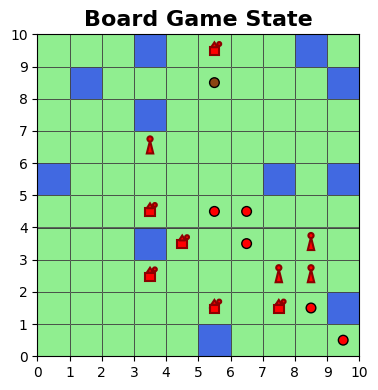

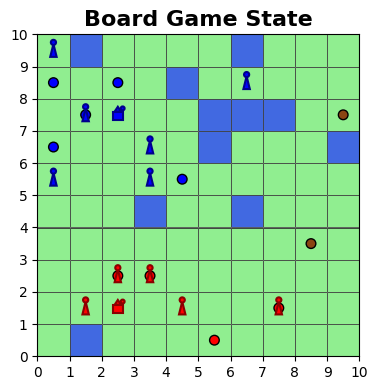

ep    2 | steps 421 | ret 102.8 | loss -85.4967


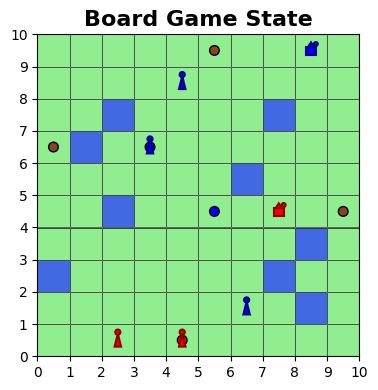

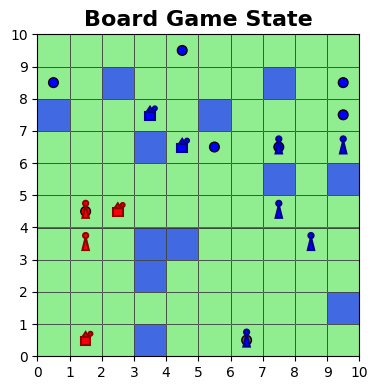

ep    4 | steps 452 | ret 89.0 | loss -122.3330


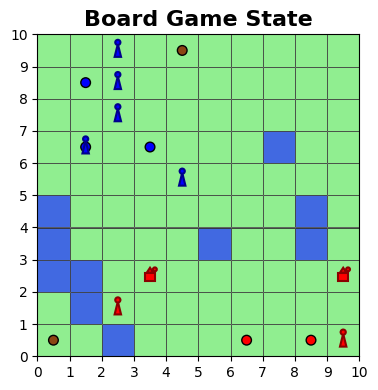

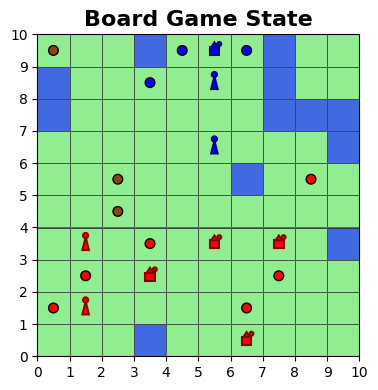

ep    6 | steps 513 | ret 106.0 | loss -126.5102


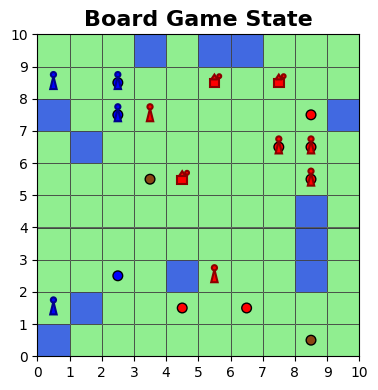

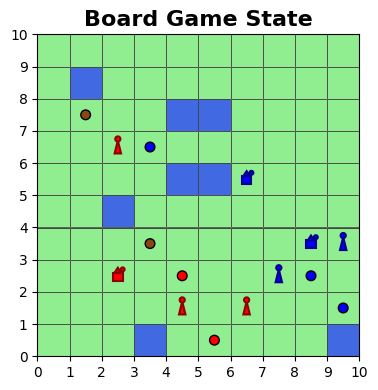

ep    8 | steps 423 | ret 79.8 | loss -99.3493


KeyboardInterrupt: 

In [14]:
policy = DummyPolicy()
opt    = torch.optim.Adam(policy.parameters(), lr=LR)

for ep in range(N_EPISODES):
    obs = env.reset()
    log_probs, rewards = [], []

    for j in range(MAX_STEPS):
        mask          = env.get_action_mask()
        action, log_p = policy(obs, mask)
        obs, reward, done, info = env.step(action)

        #if j % 20 == 0:
        #   env.render()

        log_probs.append(log_p)
        rewards.append(reward)

        if done:
            break
    env.render()

    # REINFORCE update
    returns = discount_returns(rewards)
    returns = torch.tensor(returns, dtype=torch.float32)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)

    loss = -torch.stack(log_probs) @ returns   # scalar

    opt.zero_grad()
    loss.backward()
    opt.step()

    if ep % 2 == 0:
        print(f"ep {ep:4d} | steps {len(rewards):3d} | "
              f"ret {sum(rewards):.1f} | loss {loss.item():.4f}")

In [16]:
env.game.players[0].partial_graph

array([[0., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(100, 26))

In [25]:
print([env.game.game_board.int_to_tup[tile_id] for tile_id in env.game.players[0].uncovered_tile_ids.__iter__()])

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (3, 0), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (3, 9), (4, 0), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 0), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9)]
